# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Bimo Cahyo Kusumo
- **Email:** bimochayo@gmail.com
- **ID Dicoding:** bimo_cahyo

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana pola rata-rata peminjaman sepeda sepanjang minggu?
- Pertanyaan 2: Bagaimana pola pemakaian sepeda per jam, terutama pada jam sibuk seperti pagi dan sore hari?

## Import Semua Packages/Library yang Digunakan

In [247]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [248]:
day_df = pd.read_csv("./data/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [249]:
hour_df = pd.read_csv("./data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

##### Dataframe **day_df**

In [250]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [251]:
print(f"Jumlah data null: \n{day_df.isnull().sum()}\n")

Jumlah data null: 
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64



In [252]:
print(f"Jumlah data duplikat: {day_df.duplicated().sum()}")

Jumlah data duplikat: 0


**Insight:**
- Pada dataframe day_df tidak terdapat data yang bersifat null dan terduplikasi

##### Dataframe **hour_df**

In [253]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [254]:
hour_df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [255]:
print(f"Jumlah data null: \n{hour_df.isnull().sum()}\n")

Jumlah data null: 
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64



In [256]:
print(f"Jumlah data duplikat: {hour_df.duplicated().sum()}")

Jumlah data duplikat: 0


**Insight:**
- Pada dataframe hour_df tidak terdapat data yang bersifat null dan terduplikasi

### Cleaning Data

##### Dataframe **day_df**

In [257]:
# Mapping weekday dari angka ke nama hari
weekday_map = {0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'}
day_df['weekday'] = day_df['weekday'].map(weekday_map)


In [258]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,Sabtu,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,Minggu,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,Senin,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,Selasa,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,Rabu,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Exploratory Data Analysis (EDA)

##### Dataframe **day_df**

In [259]:
print(day_df['cnt'].describe())

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64


#### Jumlah Rata-rata Rental Sepeda Tiap Harinya

In [260]:
weekday_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
day_df['weekday'] = pd.Categorical(day_df['weekday'], categories=weekday_order, ordered=True)

weekday_avg = day_df.groupby('weekday', observed=False)['cnt'].mean()

print(weekday_avg)

weekday
Senin     4338.123810
Selasa    4510.663462
Rabu      4548.538462
Kamis     4667.259615
Jumat     4690.288462
Sabtu     4550.542857
Minggu    4228.828571
Name: cnt, dtype: float64


**Insight:**
- Hari jumat menjadi hari dengan rata rata rental sepeda terbanyak, sedangkan hari minggu dengan peminjaman paling rendah

##### Dataframe **hour_df**

#### Jumlah Rata-rata Rental Sepeda Tiap Jam Dalam Sehari

In [261]:
hourly_avg = hour_df.groupby('hr')['cnt'].mean()
print(hourly_avg)

hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: cnt, dtype: float64


**Insight:**
- Pukul 17 menjadi jam dengan rata rata rental sepeda terbanyak dalam sehari, sedangkan pukul 4 yang paling rendah

##### Export Dataset ke Folder Dashboard

In [262]:
day_df.to_csv("./dashboard/day_data.csv", index=False)
hour_df.to_csv("./dashboard/hour_data.csv", index=False)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola rata-rata peminjaman sepeda sepanjang minggu?

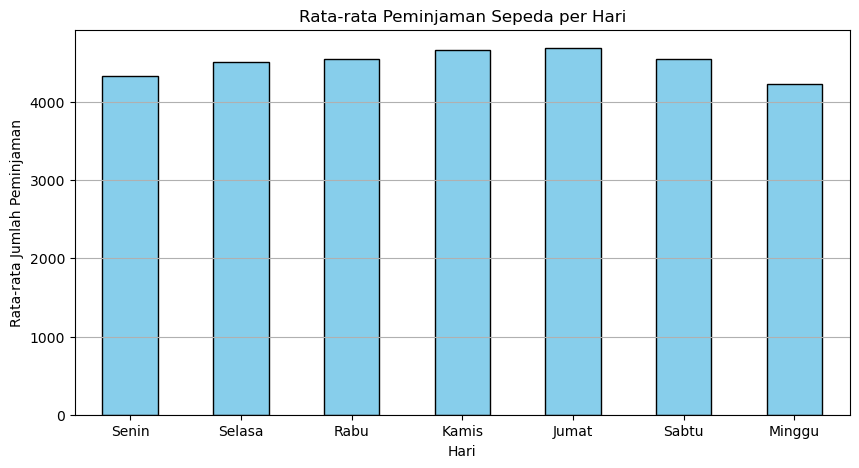

In [263]:
plt.figure(figsize=(10, 5))
weekday_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Rata-rata Peminjaman Sepeda per Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

**Insight:**
- Perbedaan antara hari-hari dalam seminggu tidak terlalu mencolok, yang menunjukkan bahwa sepeda cukup digunakan sepanjang minggu, baik untuk keperluan kerja atau rekreasi.
- Peminjaman sepeda pada hari kerja (Senin hingga Jumat) menunjukkan rata-rata peminjaman yang lebih tinggi dibandingkan dengan akhir pekan (Sabtu dan Minggu).

### Pertanyaan 2: Bagaimana pola pemakaian sepeda per jam, terutama pada jam sibuk seperti pagi dan sore hari?

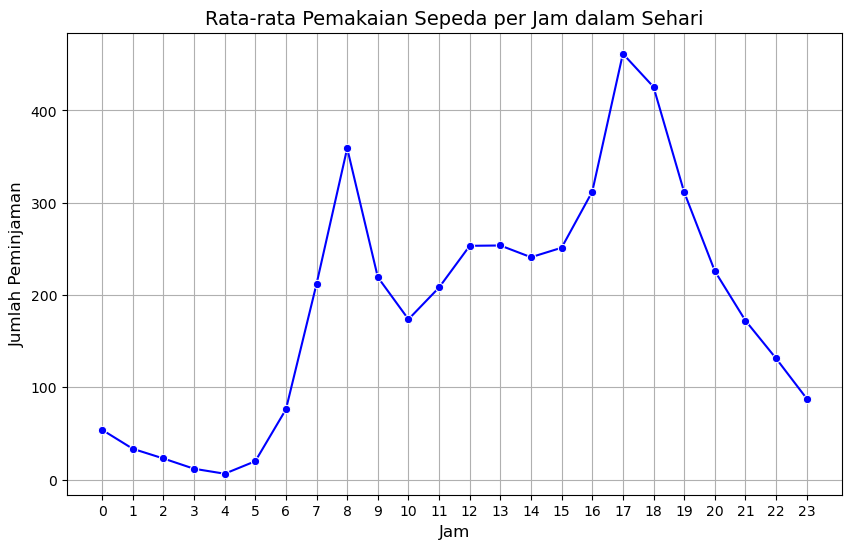

In [264]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_avg, marker='o', color='b')

plt.title('Rata-rata Pemakaian Sepeda per Jam dalam Sehari', fontsize=14)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Jumlah Peminjaman', fontsize=12)

plt.xticks(range(24))

plt.grid(True)
plt.show()

**Insight:**
- Jam 17 adalah jam dengan jumlah peminjaman sepeda tertinggi, yaitu sebanyak 461 peminjaman.
- Pemakaian sepeda cenderung lebih tinggi pada jam-jam sibuk, seperti pagi hari (sekitar jam 7-9) dan sore hari (sekitar jam 17-19), yang mungkin berhubungan dengan penggunaan sepeda untuk pergi bekerja atau pulang kerja.

## Conclusion

- Pemakaian sepeda menunjukkan tren yang stabil sepanjang minggu, dengan sedikit perbedaan antar hari. Hari kerja, dari Senin hingga Jumat, memiliki rata-rata peminjaman yang lebih tinggi dibandingkan akhir pekan. Hal ini menunjukkan bahwa sepeda digunakan lebih sering untuk keperluan sehari-hari, seperti transportasi ke tempat kerja atau sekolah, dibandingkan untuk rekreasi pada akhir pekan.


- Waktu sore hari khususnya pukul 17:00, tercatat sebagai jam dengan peminjaman sepeda tertinggi, mencapai 461 peminjaman. Selain itu, lonjakan pemakaian juga terjadi pada jam-jam pagi antara pukul 7 hingga 9 dan sore hari antara pukul 17 hingga 19. Pola ini mengindikasikan bahwa sepeda banyak digunakan sebagai moda transportasi utama saat jam sibuk, seperti saat pergi dan pulang kerja.